# Desafio 3: Um problema de Machine Learning Classico

**Objetivo:** Neste desafio vocês irão aplicar, na prática, os conceitos fundamentais de um projeto de Machine Learning supervisionado. O objetivo é desenvolver um modelo capaz de prever quais passageiros sobreviveram ao naufrágio do Titanic, utilizando o conjunto de dados disponibilizado pelo Kaggle. Mais importante do que obter uma pontuação elevada na competição é compreender e executar todas as etapas do ciclo de desenvolvimento de um projeto de Machine Learning, desde a exploração dos dados até a submissão do resultado. 

**Contexto:** O desafio **Titanic – Machine Learning from Disaster**, disponibilizado pelo Kaggle, é uma das competições mais conhecidas para introdução ao Machine Learning. Seu objetivo é construir um modelo capaz de prever se um passageiro sobreviveu ou não ao desastre do Titanic, utilizando informações como idade, sexo, classe da passagem, número de familiares, tarifa paga, entre outras. 

**Requisitos mínimos**
* Estar implementada em um único notebook Jupyter;
* Realizar a leitura da base de treinamento disponibilizada pelo Kaggle;
* Executar uma análise exploratória dos dados (EDA).
* Tratar valores ausentes, inconsistências e realizar as transformações necessárias para o treinamento do modelo;
* Treinar pelo menos um modelo de Machine Learning supervisionado para classificação;
* Gerar as previsões para a base de teste;
* Produzir o arquivo de submissão no formato exigido pelo Kaggle;
* Submeter o resultado à competição e obter uma pontuação válida

**Recomendação de boas praticas**
* Documentar as principais etapas do notebook;
* Explicar as decisões adotadas durante o tratamento dos dados;
* Comparar dois ou mais algoritmos de Machine Learning;
* Avaliar a importância das variáveis utilizadas pelo modelo;
* Organizar o código de forma clara e comentada;
* Garantir a reprodutibilidade dos resultados (por exemplo, utilizando random_state);


<font size="4">**Sumário**</font>

<font size="3">[Parte 1 - Setup e Leitura dos Dados](#1.-Setup-e-Leitura-dos-Dados)</font>

<font size="3">[Parte 2 - Análise Exploratória (EDA)](#2.-EDA-e-Tratamento-dos-Dados)</font>

<font size="3">[Parte 3 - Modelagem de Machine Learning](#3.-Modelagem-de-Machine-Learning)</font>

<font size="3">[Parte 4 - Previsões e Submissão](#4.-Previsoes-e-Submissao) </font>

---

## 1. Setup e Leitura dos Dados

### 1.1 Setup Libray

In [16]:
import math
import time

import numpy as np
import pandas as pd

# from setup_notebook import setup_path
# setup_path()
import matplotlib.pyplot as plt

import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import pearsonr

from unittest.mock import patch

from sklearn.model_selection import cross_val_score, cross_validate, StratifiedKFold

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression



import warnings

warnings.filterwarnings("ignore")

### 1.2 Utils

In [2]:
#definição da paleta de cor
color_palette21 = [
    "#004C4C", "#006666", "#008080", "#199191", "#29A3A3",
    "#40B5B5", "#55C7C7", "#66D9D9", "#80ECEC", "#99FFFF",
    "#FFD580", "#FFC460", "#FFB240", "#FFA020", "#FF8E00",
    "#FF7C00", "#FF6400", "#FF4C00", "#FF3300", "#FF1A00", "#FF0000"]

sns.set_palette(color_palette21 )


# ==================== Descrição INICIAL ====================
def inital_describe(df, simple=False):
    """
    Realiza análise exploratória inicial do DataFrame

    Parameters:
    df (pd.DataFrame): DataFrame a ser analisado
    """

    print("=" * 60)
    print("📊 ANÁLISE EXPLORATÓRIA DO DATAFRAME")
    print("=" * 60)

    # Informações sobre o shape dos dados
    print(f"\n📈 DIMENSÕES DO DATASET:")
    print(f"   • {df.shape[0]} linhas")
    print(f"   • {df.shape[1]} colunas")
    print(f"   • Total de células: {df.shape[0] * df.shape[1]:}")

    # Informações sobre tipos de dados
    print(f"\n🔧 TIPOS DE DADOS:")
    tipo_counts = df.dtypes.value_counts()
    for tipo, count in tipo_counts.items():
        print(f"   • {tipo}: {count} colunas")
    if not simple:
        # Detalhamento dos tipos de dados
        print(f"\n📋 DETALHAMENTO DOS TIPOS POR COLUNA:")
        print(df.dtypes.to_frame('Tipo').to_string())

    # Verificação de duplicatas e nulos
    print("\n" + "=" * 60)
    print("🔍 VERIFICAÇÃO DE QUALIDADE DOS DADOS")
    print("=" * 60)

    # Duplicatas
    duplicatas = df.duplicated().sum()
    print(f"\n📝 REGISTROS DUPLICADOS:")
    print(f"   • Total: {duplicatas}")
    print(f"   • Percentual: {(duplicatas / len(df)) * 100:.2f}%")

    # Valores nulos
    nulos_totais = df.isnull().sum().sum()
    nulos_por_coluna = df.isnull().sum()
    colunas_com_nulos = nulos_por_coluna[nulos_por_coluna > 0]

    print(f"\n❌ VALORES NULOS:")
    print(f"   • Total: {nulos_totais}")
    print(f"   • Percentual: {(nulos_totais / (df.shape[0] * df.shape[1])) * 100:.2f}%")

    if not colunas_com_nulos.empty:
        print(f"\n📊 COLUNAS COM VALORES NULOS:")
        for coluna, nulos in colunas_com_nulos.items():
            percentual = (nulos / len(df)) * 100
            print(f"   • {coluna}: {nulos} nulos ({percentual:.2f}%)")
    else:
        print(f"   ✓ Nenhuma coluna com valores nulos")

    if not simple:
        col_obj = df.select_dtypes(include=object).columns.tolist()
        print("\n" + "=" * 60)
        print("🔎 ANÁLISE DAS COLUNAS CATEGÓRICAS")
        print("=" * 60)
        for col in col_obj:
            if col in df.columns:
                print(f"\n{str.upper(col)}")
                print(f"Quantidade de valores únicos: {df[col].nunique()}")
                if df[col].nunique()/df.shape[0]<0.05:
                    print(f"Valores: {df[col].unique()}")

        # Estatísticas básicas para colunas numéricas
        print(f"\n📊 ESTATÍSTICAS BÁSICAS (colunas numéricas):")
        colunas_numericas = df.select_dtypes(include=['number']).columns
        if len(colunas_numericas) > 0:
            display(df[colunas_numericas].describe().T)
            # print(df[colunas_numericas].describe().T.round(2))
            # print(df[colunas_numericas].describe().T.round(2).to_string())

        else:
            print("   • Nenhuma coluna numérica encontrada")

    print("\n" + "=" * 60)
    print("✅ ANÁLISE CONCLUÍDA")
    print("=" * 60)

# ==================== PRÉ-PROCESSAMENTO ====================

def preprocess_titanic(df, df_ref=None, verbose=True):
    """
    Aplica o pipeline completo de pré-processamento do Titanic.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame a ser processado (treino ou teste).
    df_ref : pd.DataFrame, optional
        DataFrame de referência (treino) para estatísticas de imputação.
        Se None, usa o próprio df como referência (modo treino).
        USAR BASE DE TREINOS ORIGINAL QUANDO TRABALHAR COM BASE de test.
        ex:
            dfo         base de treino
            df_test_raw base de teste
            df         = preprocess_titanic(dfo.drop(columns='PassengerId'), df_ref=None, verbose=True)
            df_test    = preprocess_titanic(df_test_raw, df_ref=dfo, verbose=True)
            
    verbose : bool, default=True
        Se True, imprime resumo do processamento.
    
    Returns:
    --------
    pd.DataFrame
        DataFrame processado.
    """
    df = df.copy()
    ref = df_ref if df_ref is not None else df
    
    # ============================================================
    # PASSO 1: Criar HasCabin temporariamente se necessário
    # (para permitir imputação hierárquica que usa HasCabin)
    # ============================================================
    
    # No df: criar HasCabin temporário se Cabin existe
    if 'Cabin' in df.columns:
        df['_HasCabin_temp'] = df['Cabin'].notnull().astype(int)
    else:
        df['_HasCabin_temp'] = df.get('HasCabin', 0)  # fallback se já existe
    
    # No ref: criar HasCabin temporário se Cabin existe
    ref_temp = ref.copy()
    if 'Cabin' in ref_temp.columns:
        ref_temp['_HasCabin_temp'] = ref_temp['Cabin'].notnull().astype(int)
    else:
        ref_temp['_HasCabin_temp'] = ref_temp.get('HasCabin', 0)
    
    # ============================================================
    # PASSO 2: Imputação Hierárquica de Idade
    # ============================================================
    
    if 'Age' in df.columns:
        # Ordem de agrupamento: [Sex, Pclass, HasCabin] → [Sex, Pclass] → [Sex]
        coll_age = ['Sex', 'Pclass', '_HasCabin_temp']
        df['Age2'] = df['Age'].copy()
        
        for i in range(len(coll_age)):
            if df['Age2'].isnull().sum() > 0:
                group_cols = coll_age[0:3 - i]
                
                # Verifica se todas as colunas existem no ref_temp
                missing_cols = [c for c in group_cols if c not in ref_temp.columns]
                if missing_cols:
                    continue
                
                medians = ref_temp.groupby(group_cols)['Age'].median()
                
                # Cria chave combinada para mapear
                df['_key'] = df[group_cols].apply(lambda r: tuple(r), axis=1)
                median_map = medians.to_dict()
                df.loc[df['Age2'].isnull(), 'Age2'] = df.loc[df['Age2'].isnull(), '_key'].map(median_map)
                df.drop(columns='_key', inplace=True)
        
        # Fallback: mediana geral do ref
        df['Age2'] = df['Age2'].fillna(ref_temp['Age'].median())
        df.drop(columns='Age', inplace=True)
        df.rename(columns={'Age2': 'Age'}, inplace=True)
    
    # Remove coluna temporária
    df.drop(columns='_HasCabin_temp', inplace=True, errors='ignore')
    
    # ============================================================
    # PASSO 3: HasCabin & Deck (OFICIAIS)
    # ============================================================
    
    if 'Cabin' in df.columns:
        df['HasCabin'] = df['Cabin'].notnull().astype(int)
        df['Deck'] = df['Cabin'].apply(
            lambda x: 'U' if pd.isnull(x) or str(x)[0] == 'T' else str(x)[0]
        )
        df.drop(columns='Cabin', inplace=True)
    
    # ============================================================
    # PASSO 4: Embarked
    # ============================================================
    
    if 'Embarked' in df.columns:
        df['Embarked'] = df['Embarked'].fillna(ref['Embarked'].mode()[0])
    
    # ============================================================
    # PASSO 5: Age_Group
    # ============================================================
    
    df['Age_Group'] = pd.cut(
        df['Age'],
        bins=[0, 12, 18, 30, 50, 80],
        labels=[
            'Criança (<12)',
            'Adolescente (12-18)',
            'Adulto Jovem (19-30)',
            'Adulto (31-50)',
            'Idoso (>50)'
        ]
    )
    
    # ============================================================
    # PASSO 6: Fare
    # ============================================================
    
    if 'Fare' in df.columns:
        df['Fare'] = df['Fare'].fillna(ref['Fare'].median())
    
    # ============================================================
    # PASSO 7: FamilySize
    # ============================================================
    
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    
    # ============================================================
    # PASSO 8: Title
    # ============================================================
    
    if 'Name' in df.columns:
        df['Title'] = df['Name'].str.split(', ').str[1].str.split('.', n=1).str[0]
        df['Title'] = df['Title'].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
        common_titles = ['Mr', 'Miss', 'Mrs', 'Master']
        df['Title'] = df['Title'].apply(lambda x: x if x in common_titles else 'Rare')
    
    # ============================================================
    # PASSO 9: Remoção de colunas irrelevantes
    # ============================================================
    
    drop_cols = [c for c in ['Name', 'Ticket', 'PassengerId'] if c in df.columns]
    df.drop(columns=drop_cols, inplace=True)
    
    if verbose:
        print("=" * 50)
        print("✅ PRÉ-PROCESSAMENTO CONCLUÍDO")
        print("=" * 50)
        print(f"Colunas finais: {list(df.columns)}")
        print(f"Valores nulos restantes: {df.isnull().sum().sum()}")
    
    return df

# ==================== VISUALIZAÇÃO DOS DADOS ====================

def mult_plt2(df, kind='hist', ncols=3, max_bins=15, figsize=(16, 24),
             min_boxplot=6, paleta=None,suptitle=None):

    """
    Gera automaticamente visualizações (histogramas, boxplots ou histogramas categóricos)
    para todas as colunas de um DataFrame e retorna também os dados utilizados no gráfico.

    Parâmetros
    ----------
    df : pd.DataFrame
        DataFrame contendo as colunas para visualização.
    kind : str, padrão="hist"
        Tipo de visualização: "hist" para histograma (numérico e categórico)
        ou "box" para boxplot (apenas numérico).
    ncols : int, padrão=3
        Número de colunas no grid de subplots.
    max_bins : int, padrão=15
        Máximo de bins para histogramas numéricos.
    figsize : Tuple[int, int], padrão=(16, 24)
        Tamanho da figura.
    suptitle : str, opcional
        Título geral da figura.
    min_boxplot : int, padrão=6
        Número mínimo de valores únicos para incluir a variável em boxplot.

    Retorno
    -------
    plot_data : pd.DataFrame
        DataFrame contendo as colunas:
        ["feature", "x_value", "percentual", "contagem"]
    """

    if paleta is None:
        paleta = color_palette21

    def nice_bin_width(data_range: float, max_bins: int) -> float:
        """Calcula largura de bin 'redonda' para histogramas numéricos."""
        raw_dx = data_range / max_bins
        nice_steps = [1, 2, 2.5, 5, 10]
        scale = 10 ** math.floor(math.log10(raw_dx))
        for step in nice_steps:
            candidate = step * scale
            n_bins = math.ceil(data_range / candidate)
            if n_bins <= max_bins:
                return candidate
        return data_range / max_bins

    # Separar nome das colunas numéricas e categóricas
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

    # Para boxplot: filtrar apenas numéricas com número mínimo de valores únicos
    if kind == "box":
        cols = [col for col in num_cols if df[col].nunique() >= min_boxplot]
    else:
        cols = num_cols + cat_cols

    nrows = math.ceil(len(cols) / ncols)
    fig, ax = plt.subplots(nrows, ncols, figsize=figsize)
    ax = np.array(ax).reshape(nrows, ncols)

    if not suptitle:
        suptitle = "Distribuições (numéricas e categóricas)" if kind == "hist" else "Boxplots"
    fig.suptitle(suptitle, fontsize=18, y=1.007)

    # Lista para armazenar dados dos gráficos
    data_plot = []

    for idx, col in enumerate(cols):
        row, col_idx = divmod(idx, ncols)
        temp = df[col].dropna()
        ax_ = ax[row, col_idx]
        ax_.set_title(col)

        # --- Histogramas numéricos ---
        if kind == "hist" and col in num_cols:
            unique_vals = np.sort(temp.unique())
            if np.issubdtype(temp.dtype, np.integer) and len(unique_vals) <= 8:
                dx = 1
                align = 'center'
                bins = np.arange(min(unique_vals), max(unique_vals) + dx + 1, dx)
            else:
                data_range = temp.max() - temp.min()
                dx = nice_bin_width(data_range, max_bins)
                align = 'edge'
                bins = np.arange(temp.min(), temp.max() + dx, dx)

            counts, edges = np.histogram(temp, bins)
            perc = counts / len(temp) * 100

            ax_.bar(edges[:-1], perc, width=np.diff(bins), align=align,
                    color=paleta[2], edgecolor='black')
            #print(col,df[col].mean())
            ax_.axvline(df[col].mean(),color='red', linestyle='--', label=f'Média: {df[col].mean():.2f}')
            ax_.axvline(df[col].median(), color='green', linestyle='--',label=f'Mediana: {df[col].median():.2f}')

            ax_.legend()
            ax_.set_xlabel(col)
            ax_.set_ylabel('Percentual (%)')
            ax_.set_xticks(bins[:-1])
            if len(bins) >= 10:
                ax_.set_xticklabels(np.round(bins[:-1], 2), rotation=45)

            # Adiciona texto e registra dados
            for i in range(len(counts)):
                fs = max(6, 10- len(counts) // 8)
                fs=6

                bar_center = bins[i] if align == 'center' else bins[i] + (bins[i + 1] - bins[i]) / 2
                ax_.text(bar_center, perc[i], f'{perc[i]:.1f}%',
                         ha='center', va='bottom', fontsize=fs)

                # Adiciona ao registro
                data_plot.append({
                    "feature": col,
                    "x_value": round(bar_center, 4),
                    "percentual": round(perc[i], 2),
                    "contagem": int(counts[i])
                })

        # --- Histogramas categóricos ---
        elif kind == "hist" and col in cat_cols:
            counts = temp.value_counts()
            perc = counts / len(temp) * 100

            ax_.bar(counts.index.astype(str), perc, color=paleta[5], edgecolor='black')
            ax_.set_xlabel(col)
            ax_.set_ylabel('Percentual (%)')
            ax_.tick_params(axis='x', rotation=45)

            for i, (cat, p) in enumerate(zip(counts.index, perc)):
                ax_.text(i, p, f'{p:.1f}%', ha='center', va='bottom', fontsize=9)
                # Adiciona ao registro
                data_plot.append({
                    "feature": col,
                    "x_value": str(cat),
                    "percentual": round(p, 2),
                    "contagem": int(counts.loc[cat])
                })

        # --- Boxplots numéricos ---
        elif kind == "box":
            sns.boxplot(y=temp, color=paleta[2], ax=ax_)
            ax_.set_xlabel(col)
            ax_.set_ylabel("")

    # Remove subplots extras
    for j in range(len(cols), nrows * ncols):
        row, col_idx = divmod(j, ncols)
        ax[row, col_idx].set_visible(False)

    plt.tight_layout()
    plt.show()

    # Retornar DataFrame com os dados
    out_data = pd.DataFrame(data_plot, columns=["feature", "x_value", "percentual", "contagem"])
    return out_data

def bar_bar_cat(df, cat_1, cat_2=None, paleta=None,figsize=(12,6)):
    """
    Gráfico de barras categórico.

    - 1 categoria: distribuição simples (percentual)
    - 2 categorias: distribuição percentual condicional

    - h altura(tamanho) da figura
    - paleta de cor
    """

    if paleta is None:
        paleta = color_palette21

    #figsize = (10, h)

    # ==================================================
    # CASO 1 — APENAS UMA CATEGORIA
    # ==================================================
    if cat_2 is None:

        contagem = df[cat_1].value_counts()
        percentual = df[cat_1].value_counts(normalize=True) * 100

        df_plot = pd.DataFrame({
            cat_1: contagem.index,
            'count': contagem.values,
            'percentual': percentual.values})

        n_bars = df_plot.shape[0]
        indices = np.linspace(5, len(paleta) - 6, n_bars, dtype=int)
        custom_palette = [paleta[i] for i in indices]


        plt.figure(figsize=figsize)
        ax = sns.barplot(data=df_plot,
                         x=cat_1,
                         y='percentual',
                         palette=custom_palette,
                         edgecolor='black')

        ax.set_title(f'Distribuição de {cat_1}', fontsize=14, weight='bold')
        ax.set_xlabel(cat_1)
        ax.set_ylabel('Percentual (%)')

        for i, bar in enumerate(ax.containers[0]):
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.5,
                f'{df_plot["count"].iloc[i]} ({h:.1f}%)',
                ha='center',
                va='bottom',
                fontsize=9
            )

        plt.tight_layout()
        plt.show()
        return df_plot

    # ==================================================
    # CASO 2 — DUAS CATEGORIAS
    # ==================================================
    contagem = pd.crosstab(df[cat_1], df[cat_2])
    percentual = pd.crosstab(df[cat_1], df[cat_2], normalize='index') * 100

    df_plot = percentual.reset_index()
    df_plot = pd.melt(
        df_plot,
        id_vars=[cat_1],
        value_vars=percentual.columns,
        var_name=cat_2,
        value_name='percentual'
    )

    n_hue = percentual.shape[1]
    #indices = np.linspace(2, len(paleta) - 3, n_hue, dtype=int)
    indices = np.linspace(3, len(paleta) - 6, n_hue , dtype=int)

    custom_palette = [paleta[i] for i in indices]

    plt.figure(figsize=figsize)

    ax = sns.barplot(
        data=df_plot,
        x=cat_1,
        y='percentual',
        hue=cat_2,
        palette=custom_palette,
        edgecolor='black'
    )

    ax.set_title(f'Distribuição de {cat_2} por {cat_1}', fontsize=14, weight='bold')
    ax.set_xlabel(cat_1)
    ax.set_ylabel('Percentual (%)')
    ax.legend(title=cat_2, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)

    # Labels
    for i, container in enumerate(ax.containers):
        for j, bar in enumerate(container):
            h = bar.get_height()
            if h > 0:
                count = contagem.iloc[j, i]
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    h + 0.5,
                    f'{count} ({h:.1f}%)',
                    ha='center',
                    va='bottom',
                    fontsize=8
                )

    plt.tight_layout()
    plt.show()

    return contagem, percentual

def correlation_bar(df, target, threshold=None, paleta=None,metodo=None,plot_type='all'):
    """
    Plot heatmap and/or barplot of correlation with target variable.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with numeric variables.
    target : str
        Name of target column.
    threshold : float, optional
        Threshold to filter correlations
    plot_type : str, optional
        Type of plot:
        - 'all'  : heatmap + barplot (default)
        - 'corr' : only heatmap
        - 'bar'  : only barplot

    Returns:
    --------
    tuple
        Ordered correlation matrix and target correlation series

    """
    if paleta is None:
        paleta = color_palette21[::-1]  #[::-1] padrçao inverso de cores
    if metodo is None:
        metodo=pearson

    # --- Correlation ---
    corr = df.corr(numeric_only=True,method=metodo)

    # --- Normalization ---
    vmin, vmax = -1, 1
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    # --- Custom colormap ---
    cmap60 = LinearSegmentedColormap.from_list(
        "custom_21", paleta, N=60
    )

    # --- Sorting by target ---
    order = corr[target].sort_values(ascending=True).index
    corr_ordered = corr.loc[order, order]
    dfcm = corr_ordered.copy()

    if isinstance(threshold, (int, float)):
        dfcm[(dfcm < threshold) & (dfcm > -threshold)] = pd.NA
        dfcm[dfcm >= 0.99] = pd.NA

    # --- Correlation with target variable ---
    corr_target = dfcm[target].drop(target).sort_values(ascending=False)
    #corr_target = corr[target].drop(target).sort_values(ascending=False)

    cmap60_bar = [cmap60(norm(value)) for value in corr_target.values]

    # --- Plotting ---
    if plot_type == 'all':
        fig, axes = plt.subplots(
            1, 2,
            figsize=(18, 8),
            gridspec_kw={'width_ratios': [1.6, 0.6]}
        )
        ax_corr, ax_bar = axes
    else:
        fig, ax = plt.subplots(figsize=(10, 8))

    if plot_type in ['all', 'corr']:
        ax = ax_corr if plot_type == 'all' else ax
        fig = ax.get_figure()
        fig.set_size_inches(16, 8)
        sns.heatmap(
            dfcm,
            cmap=cmap60,
            annot=True,
            fmt=".2f",
            center=0,
            vmin=vmin,
            vmax=vmax,
            linewidths=0.4,
            cbar_kws={'label': metodo.title() +' Correlation'},
            ax=ax
        )
        ax.set_title(
            f"Correlation Map Ordered by '{target}'",
            fontsize=14,
            weight='bold'
        )

    if plot_type in ['all', 'bar']:
        ax = ax_bar if plot_type == 'all' else ax

        # CORREÇÃO: Criar DataFrame para o barplot com hue
        bar_data = pd.DataFrame({
            'features': corr_target.index,
            'correlation': corr_target.values,
            'hue': corr_target.values  # Adiciona hue baseado nos valores
        })

        sns.barplot(
            data=bar_data,
            x='correlation',
            y='features',
            #hue='hue',  # Especifica hue
            palette=cmap60_bar,
            #legend=False,  # Remove a legenda do hue
            ax=ax
        )
        ax.set_title(
            f"Variable Correlation with '{target}'",
            fontsize=14,
            weight='bold'
        )
        ax.set_xlabel(metodo.title()+" Correlation Coefficient")

        # Color bar
        sm = plt.cm.ScalarMappable(cmap=cmap60, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(
            sm,
            ax=ax,
            fraction=0.03,
            pad=0.04
        )
        cbar.set_label(
            'Correlation Scale (shared with heatmap)',
            rotation=270,
            labelpad=15
        )

    plt.tight_layout()
    plt.show()

    return corr_ordered, corr_target

# ==================== ROTINAS DE AVALIAÇÃO ====================

def metricas_classificacao(y_test, y_pred, y_probs=None, nome_modelo='Modelo', write=False):
    """
    Calcula métricas completas para classificação
    """
    # Métricas básicas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary')
    recall = recall_score(y_test, y_pred, average='binary')
    f1 = f1_score(y_test, y_pred, average='binary')
    
    # AUC-ROC (se tiver probabilidades)
    roc_auc = roc_auc_score(y_test, y_probs) if y_probs is not None else None
    
    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    
    resultados = {
        'Modelo': nome_modelo,
        'accuracy': round(accuracy, 4),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f1': round(f1, 4),
        'roc_auc': round(roc_auc, 4) if roc_auc is not None else None,
        'cm': cm
    }
    
    if write:
        print('=' * 50)
        print(f'🤖 {nome_modelo.upper()}')
        print('=' * 50)
        print(f"Acurácia:  {resultados['accuracy']:.4f}")
        print(f"Precisão:  {resultados['precision']:.4f}")
        print(f"Recall:    {resultados['recall']:.4f}")
        print(f"F1-Score:  {resultados['f1']:.4f}")
        if roc_auc is not None:
            print(f"AUC-ROC:   {resultados['roc_auc']:.4f}")
        print('-' * 50)
        print("Matriz de Confusão:")
        print(cm)
        print('=' * 50)
    
    return resultados

def best_threshold(model, X_test, y_test, start=0.3, stop=0.7, steps=41, print_results=False):
    """
    Encontra o threshold que maximiza a acurácia
    """
    y_probs = model.predict_proba(X_test)[:, 1]
    thresholds = np.linspace(start, stop, steps)
    best_threshold = 0.5
    max_acc = 0
    
    for t in thresholds:
        acc = accuracy_score(y_test, y_probs > t)
        if acc > max_acc:
            max_acc = acc
            best_threshold = t
    
    if print_results:
        print('=' * 40)
        print(f"Melhor Threshold: {best_threshold:.3f}")
        print(f"Melhor Acurácia: {max_acc:.4f}")
        print('=' * 40)
    
    return best_threshold, max_acc

def cross_validation_metrics(X, y, model, cv_folds=5, scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']):
    """
    Realiza validação cruzada e retorna métricas
    """
    # Configura validação cruzada estratificada
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    
    # Realiza validação cruzada
    cv_results = cross_validate(
        model, X, y,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )
    
    # Organiza resultados
    resultados = {}
    for metric in scoring:
        train_scores = cv_results[f'train_{metric}']
        test_scores = cv_results[f'test_{metric}']
        
        resultados[metric] = {
            'train_mean': round(train_scores.mean(), 4),
            'train_std': round(train_scores.std(), 4),
            'test_mean': round(test_scores.mean(), 4),
            'test_std': round(test_scores.std(), 4)
        }
    
    return resultados
sns.color_palette(color_palette21)

[(0.0, 0.2980392156862745, 0.2980392156862745),
 (0.0, 0.4, 0.4),
 (0.0, 0.5019607843137255, 0.5019607843137255),
 (0.09803921568627451, 0.5686274509803921, 0.5686274509803921),
 (0.1607843137254902, 0.6392156862745098, 0.6392156862745098),
 (0.25098039215686274, 0.7098039215686275, 0.7098039215686275),
 (0.3333333333333333, 0.7803921568627451, 0.7803921568627451),
 (0.4, 0.8509803921568627, 0.8509803921568627),
 (0.5019607843137255, 0.9254901960784314, 0.9254901960784314),
 (0.6, 1.0, 1.0),
 (1.0, 0.8352941176470589, 0.5019607843137255),
 (1.0, 0.7686274509803922, 0.3764705882352941),
 (1.0, 0.6980392156862745, 0.25098039215686274),
 (1.0, 0.6274509803921569, 0.12549019607843137),
 (1.0, 0.5568627450980392, 0.0),
 (1.0, 0.48627450980392156, 0.0),
 (1.0, 0.39215686274509803, 0.0),
 (1.0, 0.2980392156862745, 0.0),
 (1.0, 0.2, 0.0),
 (1.0, 0.10196078431372549, 0.0),
 (1.0, 0.0, 0.0)]

In [3]:
# 2-Dataload & Pré-visualização dos Dados
dfo = pd.read_csv("/home/akel/PycharmProjects/Kaggle/Titanic/data/raw/train.csv")
df=dfo.drop(columns='PassengerId')

---
## 2. EDA e Tratamento dos Dados

In [4]:
inital_describe(df)

📊 ANÁLISE EXPLORATÓRIA DO DATAFRAME

📈 DIMENSÕES DO DATASET:
   • 891 linhas
   • 11 colunas
   • Total de células: 9801

🔧 TIPOS DE DADOS:
   • object: 5 colunas
   • int64: 4 colunas
   • float64: 2 colunas

📋 DETALHAMENTO DOS TIPOS POR COLUNA:
             Tipo
Survived    int64
Pclass      int64
Name       object
Sex        object
Age       float64
SibSp       int64
Parch       int64
Ticket     object
Fare      float64
Cabin      object
Embarked   object

🔍 VERIFICAÇÃO DE QUALIDADE DOS DADOS

📝 REGISTROS DUPLICADOS:
   • Total: 0
   • Percentual: 0.00%

❌ VALORES NULOS:
   • Total: 866
   • Percentual: 8.84%

📊 COLUNAS COM VALORES NULOS:
   • Age: 177 nulos (19.87%)
   • Cabin: 687 nulos (77.10%)
   • Embarked: 2 nulos (0.22%)

🔎 ANÁLISE DAS COLUNAS CATEGÓRICAS

NAME
Quantidade de valores únicos: 891

SEX
Quantidade de valores únicos: 2
Valores: ['male' 'female']

TICKET
Quantidade de valores únicos: 681

CABIN
Quantidade de valores únicos: 147

EMBARKED
Quantidade de valores único

,count,mean,std,min,25%,50%,75%,max
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292



✅ ANÁLISE CONCLUÍDA


### 2.1 Pré-processamento de Dados

Com base na análise exploratória, aplicaram-se transformações no conjunto de dados por meio da função ***`preprocess_titanic()`***, assim

**A. `HasCabin` e `Deck`**
- **`HasCabin`**: variável binária (1 para presença de cabine, 0 para ausência) criada a partir de `Cabin`.
- **`Deck`**: extração da letra inicial do código da cabine. Valores nulos e o convés `'T'` (raro) foram agrupados em `'U'` (*Unknown*). A coluna original `Cabin` é removida.

**B. `Embarked`**
- Imputação de valores ausentes pela moda, devido ao baixo volume de dados faltantes.

**C. Imputação Hierárquica de `Age`**

Preenchimento dos valores ausentes de idade por meio de imputação hierárquica regressiva, utilizando a mediana nos seguintes níveis de agrupamento, em ordem decrescente de especificidade:

1. `Sex`, `Pclass` e `HasCabin`;
2. `Sex` e `Pclass`;
3. `Sex`;
4. Mediana geral da base (fallback).

**D. `Age_Group`**
- Categorização em faixas etárias: *Criança (<12)*, *Adolescente (12–18)*, *Adulto Jovem (19–30)*, *Adulto (31–50)* e *Idoso (>50)*.

**E. `Fare`**
- Imputação de valores ausentes pela mediana geral da coluna.

**F. `FamilySize`**
- Cálculo: `SibSp` + `Parch` + 1 (próprio passageiro).

**G. `Title`**
- Extração do título a partir de `Name`. Padronização: `Mlle`/`Ms` → `Miss`, `Mme` → `Mrs`. Títulos raros (fora de `Mr`, `Miss`, `Mrs`, `Master`) foram agrupados em `'Rare'`.

**H. Remoção de Colunas**
- Exclusão de `Name` e `Ticket` por não serem utilizadas diretamente nas etapas subsequentes.

---
**Resumo**

* **Aproveitamento de dados incompletos:** Criação de **HasCabin** e **Deck**, além da remoção de `Cabin`.
* **Tratamento rigoroso de nulos:** Imputação hierárquica e condicional para **Age** (agrupada por sexo, classe e cabine), além de preenchimento por moda (**Embarked**) e mediana (**Fare**).
* **Engenharia de recursos (Feature Engineering):** Construção de variáveis explicativas como **Age_Group**, **FamilySize** e **Title** (com aglutinação de títulos raros).
* **Limpeza estrutural:** Exclusão de identificadores de texto sem valor preditivo direto (`Name` e `Ticket`).




In [5]:
df = preprocess_titanic(dfo.drop(columns='PassengerId'), verbose=True)

✅ PRÉ-PROCESSAMENTO CONCLUÍDO
Colunas finais: ['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Age', 'HasCabin', 'Deck', 'Age_Group', 'FamilySize', 'Title']
Valores nulos restantes: 0


### 2.2 Distribuição dos Dados

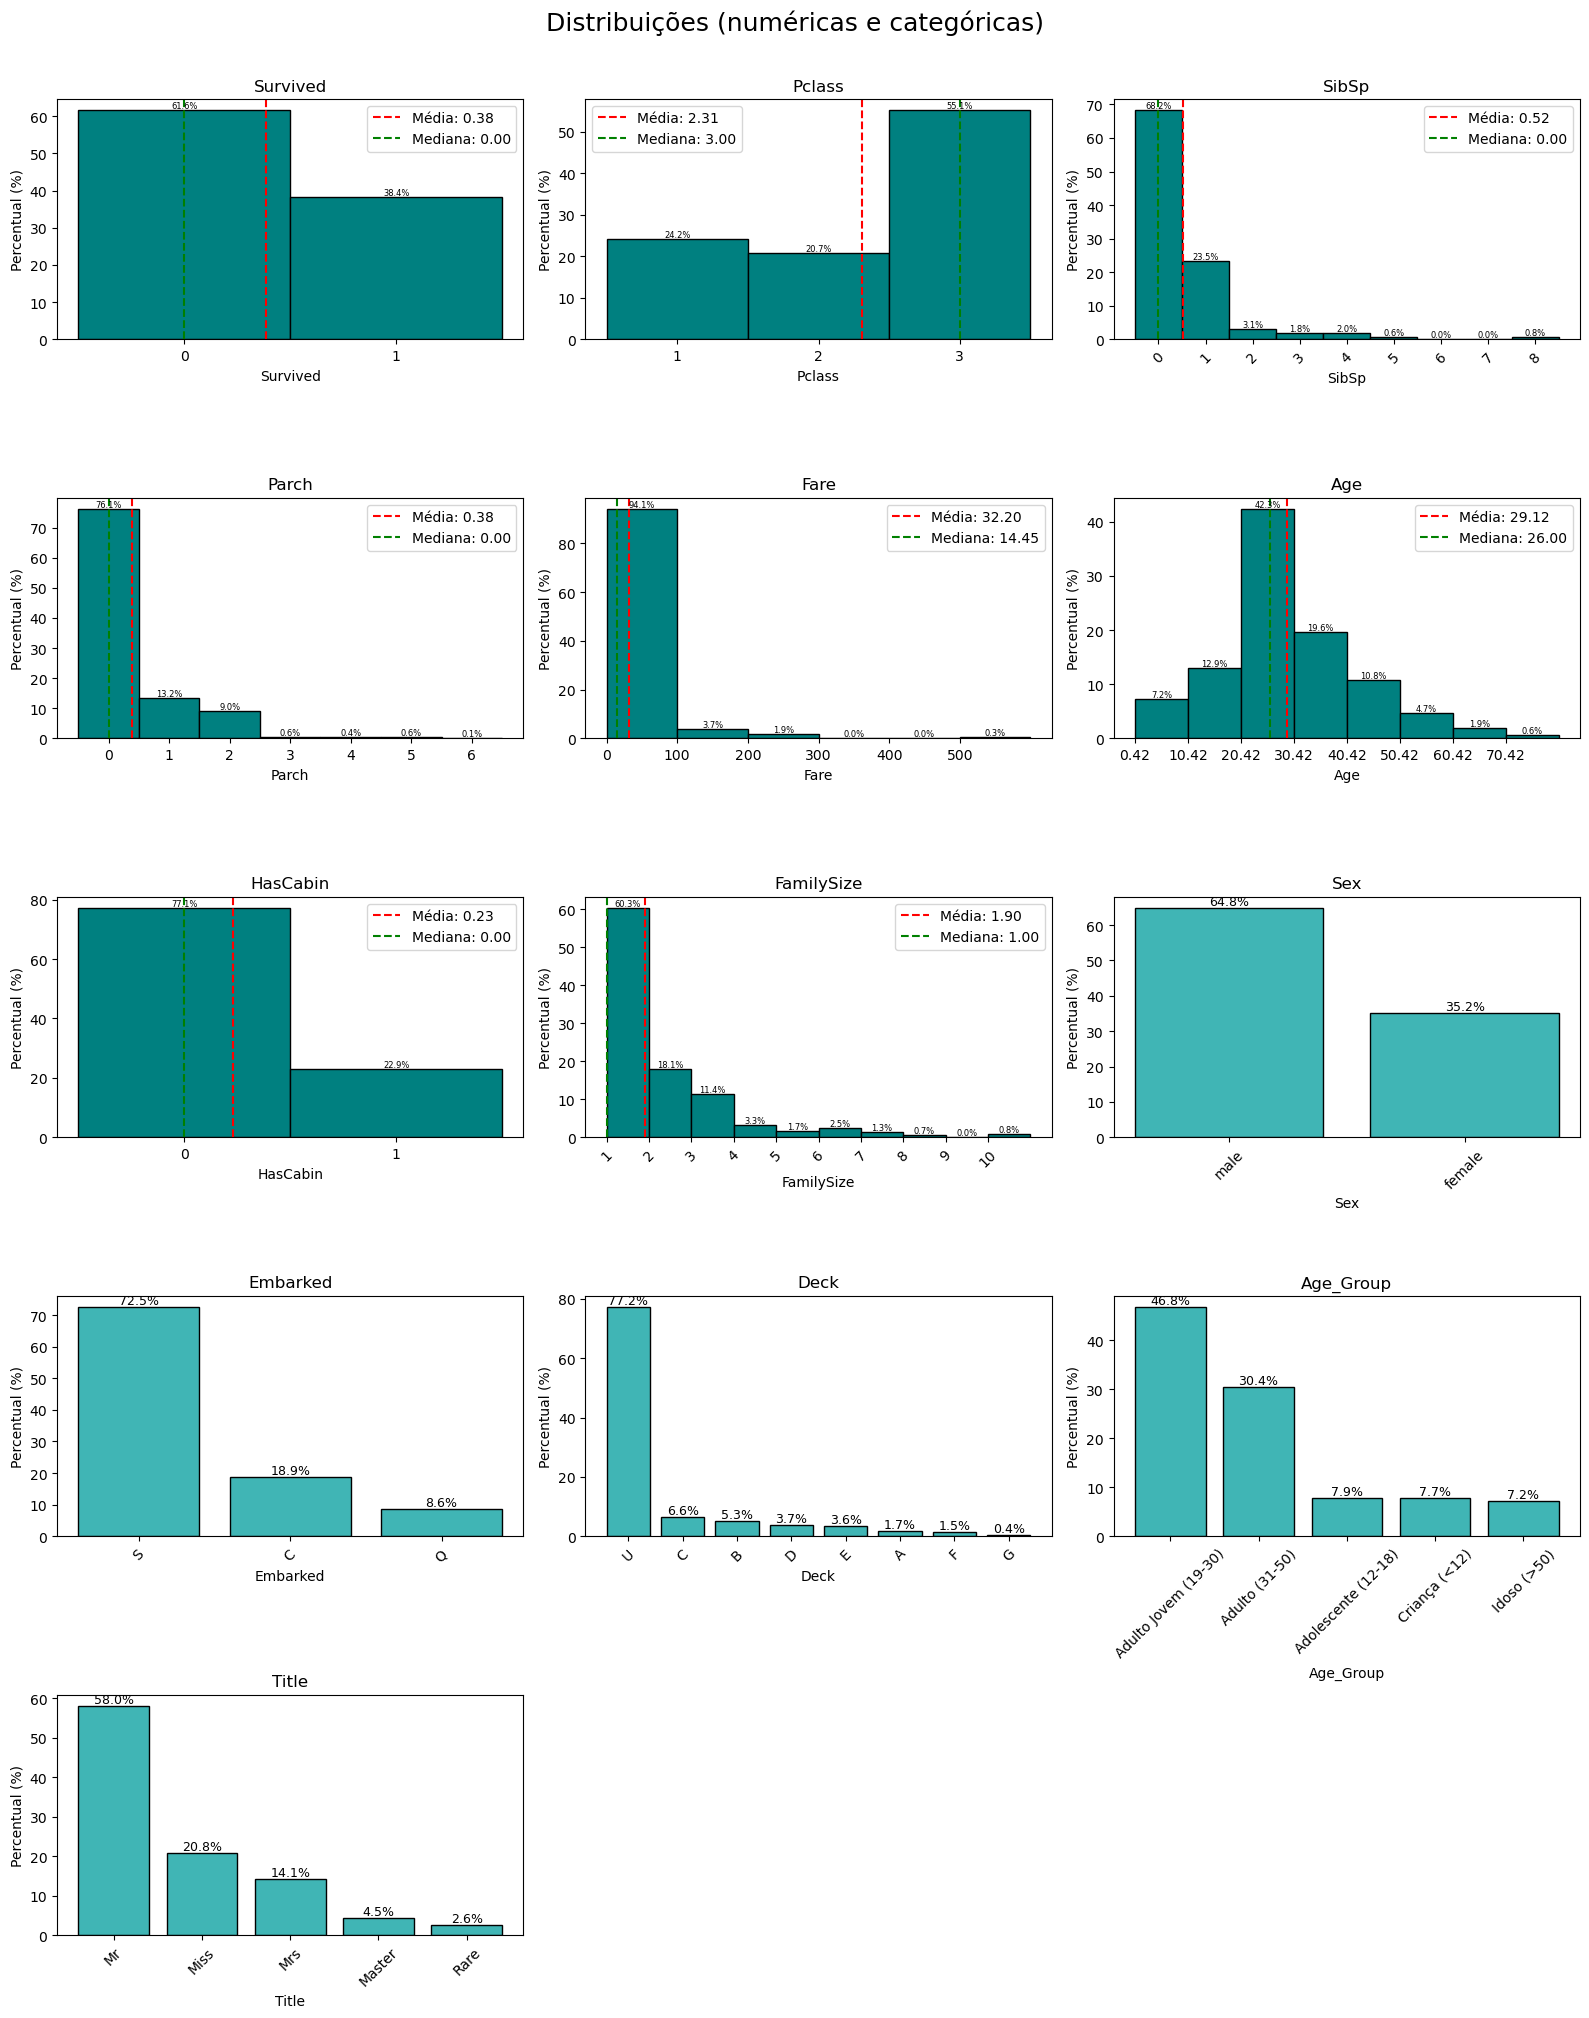

In [6]:
out=mult_plt2(df,ncols=3,max_bins=10,figsize=(16,20))

**Perfil sociodemográfico e familiar**

A maioria dos passageiros era do sexo masculino (\~64%), adulta jovem (19–30 anos: \~47%) e pertencia à 3ª classe (\~55%), com títulos predominantes de "Mr" (\~58%). Em termos familiares, grande parte viajava sem parentes a bordo (SibSp=0: \~68%; Parch=0: \~76%), e o tamanho familiar mais comum foi de 1,5 pessoa (\~60%). A maioria não possuía cabine registrada (\~77%) ou estava no deck desconhecido "U" (\~77%), e as tarifas pagas foram majoritariamente baixas (até 50 unidades: \~94%).

**Sobrevivência, embarque e distribuição etária**

A taxa de sobrevivência geral foi de apenas \~38%, contra 61% de não sobreviventes. O porto de embarque mais frequente foi Southampton (S), com \~72% dos passageiros. Quanto à idade, além dos adultos jovens, os demais grupos etários incluíam adultos (31–50 anos: \~30), adolescentes (\~8%), crianças (\~8%) e idosos (\~7%). Os títulos femininos ("Miss" e "Mrs") somaram cerca de \~35%, enquanto títulos raros representaram apenas \~2,5% da amostra.

### 2.3 Análise Univariada da Sobrevivência
Com base nas estatísticas geradas, esta seção sumariza os principais achados para cada conjunto de variáveis, evidenciando a taxa de sobrevivência observada em cada grupo (1: sobreviveu; 0: não sobreviveu).

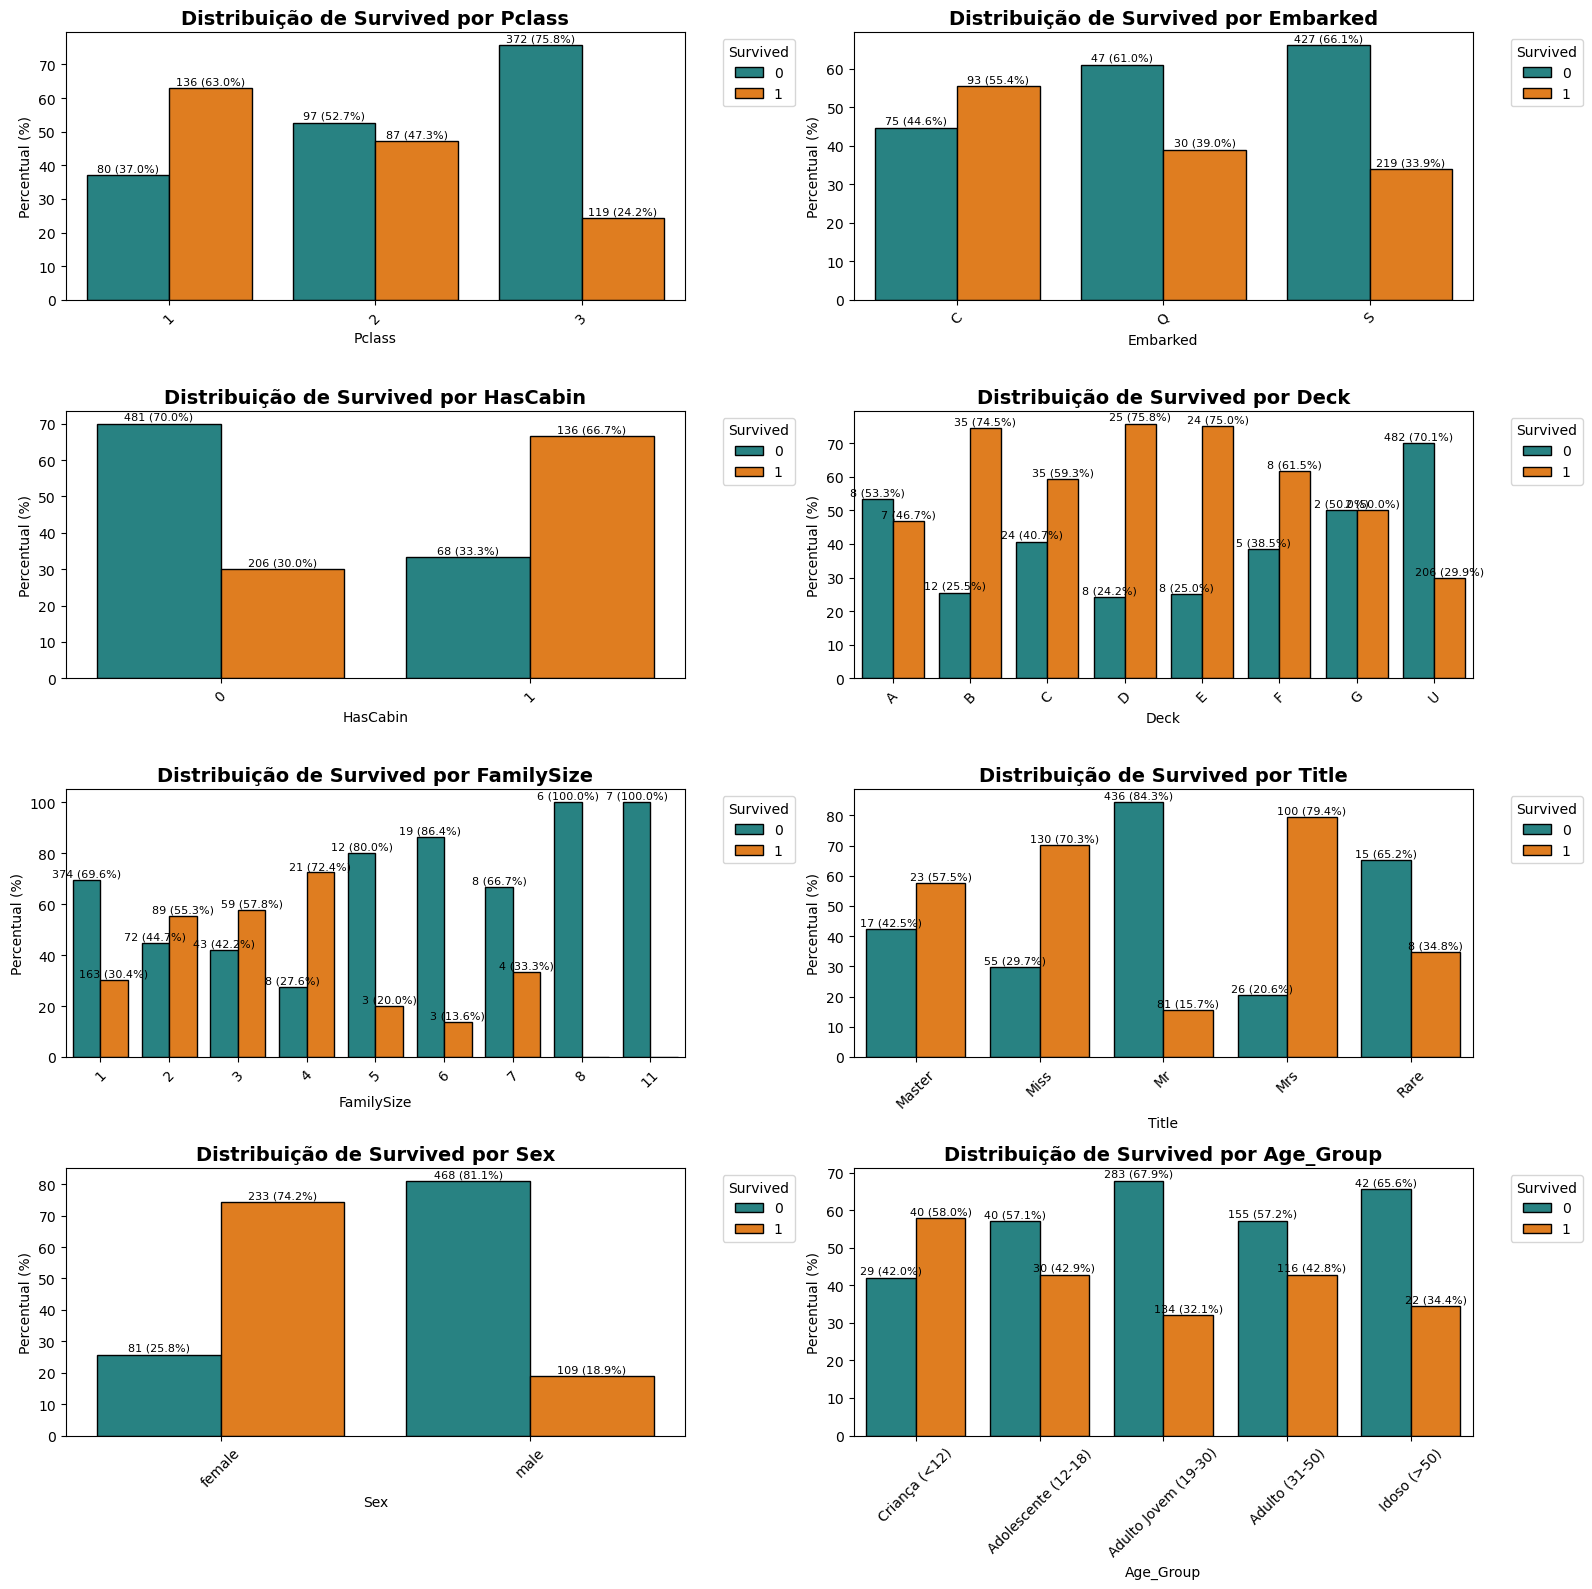

In [7]:
# 1. Cria a figura do grid 2x2
fig, axes = plt.subplots(4, 2, figsize=(16, 16))

# Mapeia cada subplot para a coluna do seu DataFrame
stat = {}
variaveis = [
    ("Pclass", axes[0, 0]),
    ("Embarked", axes[0, 1]),
    ("HasCabin", axes[1, 0]),
    ("Deck", axes[1, 1]),
    ("FamilySize", axes[2, 0]),
    ("Title", axes[2, 1]),
    ("Sex", axes[3, 0]),
    ("Age_Group", axes[3, 1])]

# 2. Desativa o plt.show e plt.figure temporariamente
with (
    patch("matplotlib.pyplot.show"),
    patch("matplotlib.pyplot.figure"),
    patch("matplotlib.pyplot.tight_layout"),
):
    for col, ax in variaveis:
        # Define o eixo atual do Matplotlib
        plt.sca(ax)
        

        # Chama a sua função original sem modificá-la
        stat[col]=bar_bar_cat(df, col, "Survived", figsize=(10, 5))

# 3. Ajusta o layout final do grid e exibe
plt.tight_layout()
plt.show()

**A. Classe do Passageiro (`Pclass`)**

* Existe uma correlação direta entre classe social e sobrevivência. Passageiros da 1ª classe tiveram a maior taxa de sobrevivência  (\~63%), seguidos pela 2ª classe (~47%).
* A 3ª classe foi a mais impactada, com a grande maioria não sobrevivendo (apenas ~24% de sobrevivência em um grupo de 491 pessoas).

**B. Porto de Embarque (`Embarked`)**

* Passageiros que embarcaram em Cherbourg (`C`) tiveram a maior taxa de sobrevivência (~55%).
* Aqueles que embarcaram em Southampton (`S`) e Queenstown (`Q`) registraram taxas significativamente menores (~34% e ~39%, respectivamente).

**C. Presença de Cabine (`HasCabin`)**

* Ter uma cabine registrada foi um forte indicador positivo: ~67% dos passageiros com cabine sobreviveram.
* Em contraste, aqueles sem registro de cabine (`0`) tiveram apenas ~30% de chance de sobrevivência.

**D. Convés (`Deck`)**

* Os conveses **B, D e E** apresentaram as maiores taxas de sobrevivência, todas na faixa de 74% a 76%.
* O grupo `U` (Desconhecido/Sem cabine) teve a menor taxa, com quase 70% de mortalidade, reforçando o achado da variável `HasCabin`.

**E. Tamanho da Família (`FamilySize`)**

* Viajar sozinho (tamanho 1) resultou em uma baixa taxa de sobrevivência (~30%).
* Famílias pequenas a médias (2 a 4 pessoas) apresentaram as melhores chances, variando de 55% a 72% de sobrevivência (o pico de sucesso foi em famílias de 4 pessoas).
* Famílias grandes (5 ou mais pessoas) sofreram quedas drásticas na sobrevivência, chegando a 0% para famílias de 8 e 11 membros.

**F. Título (`Title`)**

* Títulos femininos dominaram as taxas de sobrevivência: `Mrs` (~79%) e `Miss` (~70%).
* O título `Master` (meninos) teve **~58%** de sobrevivência.
* O título `Mr` (homens adultos) registrou a pior taxa, com impressionantes 84% de não sobreviventes.

**G. Sexo (`Sex`)**

* A diferença de gênero é a mais gritante do conjunto de dados: mulheres tiveram ~74% de chance de sobrevivência, enquanto homens tiveram apenas ~19%.

**H. Faixa Etária (`Age_Group`)**

* Crianças (<12 anos) foram o único grupo etário com mais sobreviventes do que vítimas (~58% de sobrevivência).
* Adultos Jovens (19-30 anos) e Idosos (>50 anos) registraram as maiores taxas de mortalidade em seus grupos, com apenas ~32% e ~34% de sobrevivência, respectivamente.

### 2.4. Correlação de Spearman

A matriz de correlação de Spearman confirma de forma quantitativa as tendências observadas na análise categórica e revela como as variáveis interagem entre si:

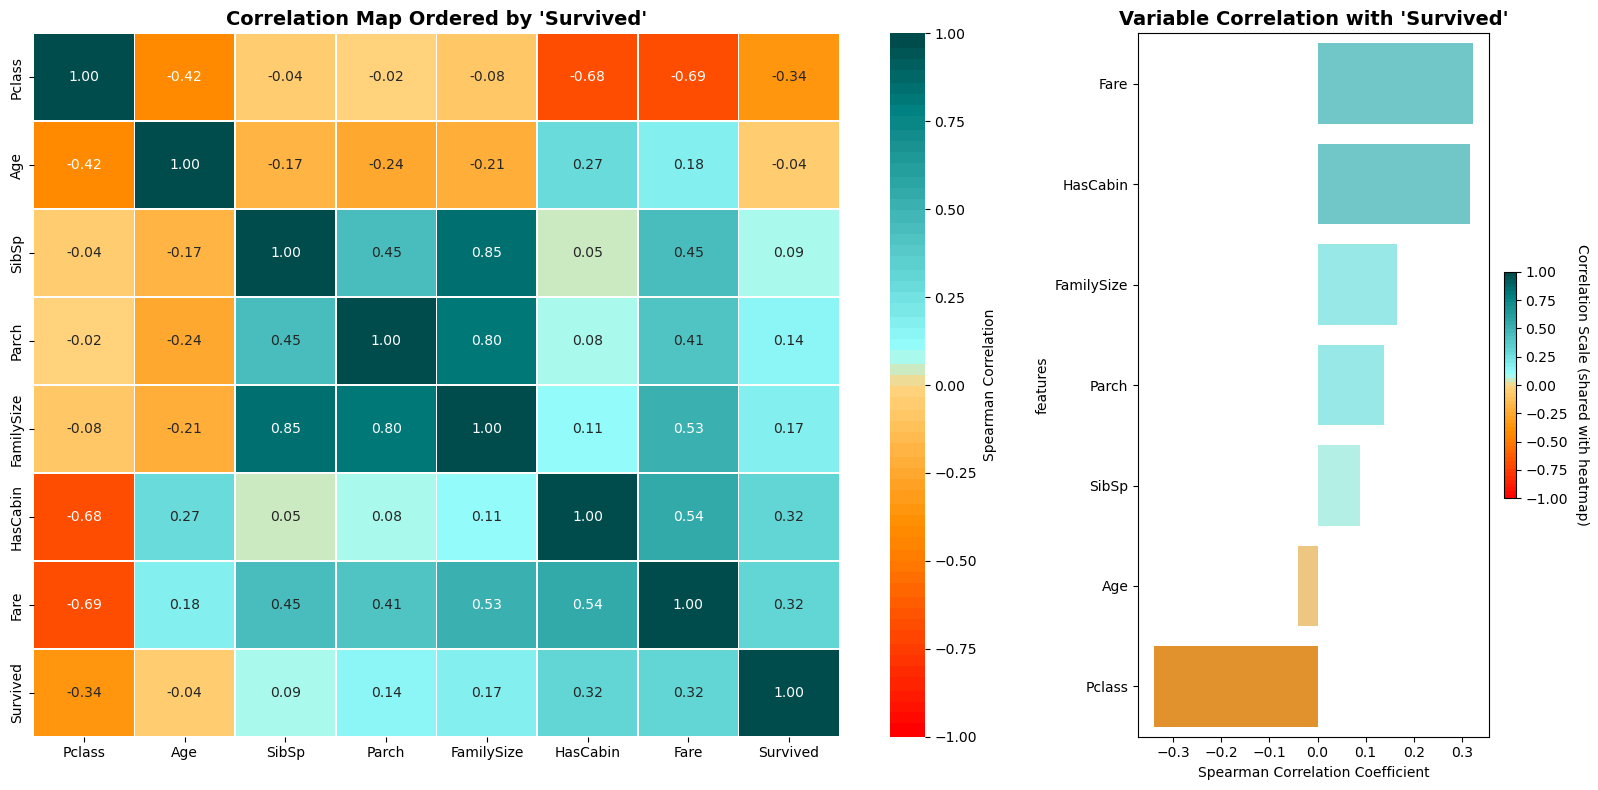

In [8]:
#Correlação
corr_vars = ['Survived','Pclass','Fare','Age','FamilySize','Title','SibSp','Parch','HasCabin']
corr,corr_tag=correlation_bar(df[corr_vars],'Survived',metodo='spearman')


**Correlações com a Sobrevivência (`Survived`):**

* **Status Socioeconômico:** As variáveis `Fare` (0.32) e `HasCabin` (0.32) apresentam correlação positiva moderada com a sobrevivência, enquanto `Pclass` (-0.34) apresenta uma correlação negativa moderada. Isso quantifica a regra de que quanto maior o poder aquisitivo (maior tarifa, presença de cabine, menor o número numérico da classe), maiores as chances de sobreviver.
* **Tamanho da Família:** `FamilySize` (0.17) e `Parch` (0.14) mostram correlações positivas fracas com a sobrevivência. Isso reflete o benefício de viajar acompanhado, embora a força da correlação seja diluída pelo fato de famílias excessivamente grandes terem altas taxas de mortalidade.
* **Idade:** A variável `Age` (-0.04) quase não apresenta correlação linear monotônica com a sobrevivência. Isso ocorre porque o impacto da idade não é uma linha reta (crianças sobreviveram muito, adultos em idade produtiva morreram mais, e idosos também morreram mais), o que explica a correlação próxima a zero.

**Correlações entre as Variáveis Preditoras (Colinearidade):**

* Existe uma fortíssima interdependência entre `Pclass`, `Fare` (-0.69) e `HasCabin` (-0.68). Isso significa que essas três variáveis estão contando essencialmente a mesma história: a 1ª classe paga tarifas mais altas e tem acesso a cabines.
* Naturalmente, `FamilySize` possui uma correlação muito forte com `SibSp` (0.85) e `Parch` (0.80), validando a construção correta da variável derivada.

### 2.6. Principais Insights e Conclusões (Resumo Geral)

A análise revela que a sobrevivência no Titanic não foi um evento aleatório, mas sim fortemente governada por regras sociais da época e condições logísticas:

1. **A Regra "Mulheres e Crianças Primeiro" prevaleceu:** A discrepância gigantesca nas taxas de sobrevivência entre os sexos (74% mulheres vs 19% homens) e títulos (`Mrs`/`Miss`/`Master` vs `Mr`), além do fato de as crianças serem a única faixa etária com saldo positivo de sobrevivência, comprova que este protocolo foi rigorosamente seguido. A ausência de correlação linear da idade na matriz de Spearman reforça que a sobrevivência de jovens não seguiu uma regra contínua, mas sim categórica ("criança" vs "adulto").
2. **O Peso do Status Socioeconômico:** Riqueza e privilégio traduziram-se diretamente em sobrevivência. Passageiros da 1ª classe e aqueles com cabines designadas (especialmente nos conveses B, D e E) sobreviveram em proporções muito maiores que os da 3ª classe. As fortes correlações de Spearman entre `Pclass`, `Fare`, `HasCabin` e `Survived` consolidam que o status econômico foi o segundo maior fator de resgate.
3. **O Paradoxo do Tamanho da Família:** Estar acompanhado ajudou, mas apenas até certo ponto. Passageiros solitários tiveram dificuldade (provavelmente por falta de auxílio mútuo ou foco no resgate), e famílias pequenas (2 a 4 pessoas) encontraram o "ponto ideal" de mobilidade e suporte. No entanto, famílias muito grandes (5+) tornaram-se âncoras logísticas: o esforço para manter um grande grupo unido no caos quase sempre resultou em tragédia.

---
## 3. Modelagem de Machine Learning

### 3.1 Separação das Bases de Treino e Validação

In [9]:
X = df.drop('Survived', axis=1)    #  X contém todas as colunas exceto 'Survived'
y = df['Survived']                 # Y contém apenas a coluna 'Purchased'
X_train, X_val, y_train,y_val = train_test_split(X, y, test_size=0.3, random_state=42)

### 3.2 Processamento Final (Encoding)
As variáveis categóricas foram convertidas para formato numérico: ordinais (`Deck`, `Title`, `Age_Group`) com `LabelEncoder`, e nominais (`Sex`, `Embarked`) com `One-Hot Encoding`. As colunas do conjunto de validação foram alinhadas às do treino.


In [24]:
# ============================================================
# CODIFICAÇÃO DE VARIÁVEIS CATEGÓRICAS
# ============================================================

X_train_enc = X_train.copy()
X_val_enc = X_val.copy()

# Definição das colunas
ordinal_cols = ['Deck', 'Title', 'Age_Group']
nominal_cols = ['Sex', 'Embarked']

# 1. LabelEncoder para variáveis ordinais 
label_encoders = {}
for col in ordinal_cols:
    le = LabelEncoder()
    X_train_enc[col] = le.fit_transform(X_train[col])
    X_val_enc[col] = le.transform(X_val[col])
    label_encoders[col] = le

# 2. One-Hot Encoding para variáveis nominais
X_train_enc = pd.get_dummies(X_train_enc, columns=nominal_cols, drop_first=True)
X_val_enc = pd.get_dummies(X_val_enc, columns=nominal_cols, drop_first=True)

# 3. Alinhamento das colunas
X_val_enc = X_val_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# 4. Verificação
print(f"Colunas no treino     : {X_train_enc.shape[1]}")
print(f"Colunas na validação  : {X_val_enc.shape[1]}")
display(X_train_enc.head())

Colunas no treino     : 13
Colunas na validação  : 13


,Pclass,SibSp,Parch,Fare,Age,HasCabin,Deck,Age_Group,FamilySize,Title,Sex_male,Embarked_Q,Embarked_S
445,1,0,2,81.8583,4.0,1,0,3,3,0,True,False,True
650,3,0,0,7.8958,25.0,0,7,2,1,2,True,False,True
172,3,1,1,11.1333,1.0,0,7,3,3,1,False,False,True
450,2,1,2,27.7500,36.0,0,7,1,4,2,True,False,True
314,2,1,1,26.2500,43.0,0,7,1,3,2,True,False,True


### 3.3 Treinamento dos Modelos

In [27]:
# ============================================
# 3.3 Treinamento dos Modelos
# ============================================

# A) RANDOM FOREST
# Params ajustados: limitamos profundidade e exigimos mais amostras por folha,
# isso reduz a capacidade da árvore de "decorar" o treino.
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=5,
    min_samples_split=10,
    random_state=42
)
rf.fit(X_train_enc, y_train)
y_pred_rf = rf.predict(X_val_enc)
y_probs_rf = rf.predict_proba(X_val_enc)[:, 1]

# B) REGRESSÃO LOGISTICA
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_enc, y_train)
y_pred_lr = logreg.predict(X_val_enc)
y_probs_lr = logreg.predict_proba(X_val_enc)[:, 1]

### 3.4 Métricas avaliação dos modelos

In [26]:
# ============================================
# A) Métricas no conjunto de validação
# ============================================

print("="*50)
print("📊 MÉTRICAS NO CONJUNTO DE VALIDAÇÃO")
print("="*50)

metricas_rf = metricas_classificacao(y_val, y_pred_rf, y_probs_rf, 'Random Forest', write=True)
metricas_lr = metricas_classificacao(y_val, y_pred_lr, y_probs_lr, 'Regressão Logística', write=True)

# ============================================
# B) Validação Cruzada (única chamada por modelo)
# ============================================

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

print("\n" + "="*50)
print("🔄 VALIDAÇÃO CRUZADA (5 FOLDS)")
print("="*50)

cv_rf = cross_validation_metrics(X_train_enc, y_train, rf, cv_folds=5, scoring=scoring)
cv_lr = cross_validation_metrics(X_train_enc, y_train, logreg, cv_folds=5, scoring=scoring)

for nome, cv_results in [('Random Forest', cv_rf), ('Regressão Logística', cv_lr)]:
    print(f"\n🤖 {nome.upper()}")
    for metric, values in cv_results.items():
        print(f"  {metric:<10} | Treino: {values['train_mean']:.4f} (±{values['train_std']:.4f})  "
              f"| Teste: {values['test_mean']:.4f} (±{values['test_std']:.4f})")

# ============================================
# C) Comparação entre modelos (CV, que é a métrica mais confiável)
# ============================================

print("\n" + "="*50)
print("📊 COMPARAÇÃO ENTRE MODELOS (média CV)")
print("="*50)
print(f"\n{'Métrica':<12} {'RF':<10} {'LogReg':<10} {'Diferença':<10}")
print("-" * 45)
for metric in scoring:
    rf_score = cv_rf[metric]['test_mean']
    lr_score = cv_lr[metric]['test_mean']
    print(f"{metric:<12} {rf_score:.4f}    {lr_score:.4f}    {rf_score - lr_score:+.4f}")

# ============================================
# D) Diagnóstico de Overfitting (antes vs depois do ajuste)
# ============================================

print("\n" + "="*50)
print("✅ DIAGNÓSTICO DE OVERFITTING")
print("="*50)

overfit_threshold = 0.05
for nome, cv_results in [('Random Forest', cv_rf), ('Regressão Logística', cv_lr)]:
    print(f"\n🤖 {nome}")
    for metric in ['accuracy', 'f1']:
        train_mean = cv_results[metric]['train_mean']
        test_mean = cv_results[metric]['test_mean']
        diff = train_mean - test_mean
        status = "⚠️  POSSÍVEL OVERFITTING" if diff > overfit_threshold else "✅ OK"
        print(f"  {metric.upper()}: Treino={train_mean:.4f}, Teste={test_mean:.4f}, Dif={diff:.4f} {status}")

# ============================================
# E) Importância das Features (modelo escolhido: RF ajustada)
# ============================================


print("\n" + "="*50)
print("🔍 TOP 10 FEATURES MAIS IMPORTANTES (Random Forest)")
print("="*50)

feature_importance = pd.DataFrame({
    'feature': X_train_enc.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(10).to_string(index=False))

feature_importance = pd.DataFrame({
    'feature': X_train_enc.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(10).to_string(index=False))

📊 MÉTRICAS NO CONJUNTO DE VALIDAÇÃO
🤖 RANDOM FOREST
Acurácia:  0.8134
Precisão:  0.8352
Recall:    0.6847
F1-Score:  0.7525
AUC-ROC:   0.8919
--------------------------------------------------
Matriz de Confusão:
[[142  15]
 [ 35  76]]
🤖 REGRESSÃO LOGÍSTICA
Acurácia:  0.8246
Precisão:  0.8265
Recall:    0.7297
F1-Score:  0.7751
AUC-ROC:   0.8743
--------------------------------------------------
Matriz de Confusão:
[[140  17]
 [ 30  81]]

🔄 VALIDAÇÃO CRUZADA (5 FOLDS)

🤖 RANDOM FOREST
  accuracy   | Treino: 0.8740 (±0.0084)  | Teste: 0.8426 (±0.0292)
  precision  | Treino: 0.8865 (±0.0186)  | Teste: 0.8545 (±0.0653)
  recall     | Treino: 0.7576 (±0.0181)  | Teste: 0.7008 (±0.0732)
  f1         | Treino: 0.8167 (±0.0127)  | Teste: 0.7663 (±0.0461)
  roc_auc    | Treino: 0.9172 (±0.0050)  | Teste: 0.8633 (±0.0329)

🤖 REGRESSÃO LOGÍSTICA
  accuracy   | Treino: 0.8094 (±0.0116)  | Teste: 0.7929 (±0.0421)
  precision  | Treino: 0.7722 (±0.0186)  | Teste: 0.7470 (±0.0752)
  recall     | Tre

---

## 4. Previsoes e Submissao
### 4.1 Leitura e processamento da base de teste

In [12]:
# ============================================
# Carregamento e processamento da base de teste
# ============================================
df_test_raw = pd.read_csv("/home/akel/PycharmProjects/Kaggle/Titanic/data/raw/test.csv")
# Guardar PassengerId para o arquivo de submissão
passenger_ids = df_test_raw['PassengerId'].copy()

print("=" * 50)
print("📊 BASE DE TESTE CARREGADA")
print("=" * 50)
print(f"Dimensões: {df_test_raw.shape[0]} linhas × {df_test_raw.shape[1]} colunas")
print(f"Colunas: {list(df_test_raw.columns)}")
print(f"Valores nulos por coluna:")
print(df_test_raw.isnull().sum()[df_test_raw.isnull().sum() > 0])

df_test = preprocess_titanic(df_test_raw, df_ref=dfo, verbose=True)

ordinal_cols = ['Deck', 'Title', 'Age_Group']
nominal_cols = ['Sex', 'Embarked']
X_test_enc = df_test.copy()

# APLICA os mesmos encoders salvos (sem dar fit novamente)
for col in ordinal_cols:
    le = label_encoders[col]
    # Trata categorias que possam existir no teste mas não no treino
    X_test_enc[col] = X_test_enc[col].astype(str).map(lambda s: s if s in le.classes_ else '<unknown>')
    X_test_enc[col] = le.transform(X_test_enc[col])

# One-Hot Encoding
X_test_enc = pd.get_dummies(X_test_enc, columns=nominal_cols, drop_first=True)

# CRUCIAL: Alinhar o teste com as colunas do TREINO
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print(f"Colunas no treino:  {X_train_enc.shape[1]}")
print(f"Colunas no teste:   {X_test_enc.shape[1]}")
print(f"Alinhadas? {list(X_train_enc.columns) == list(X_test_enc.columns)}")

📊 BASE DE TESTE CARREGADA
Dimensões: 418 linhas × 11 colunas
Colunas: ['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
Valores nulos por coluna:
Age       86
Fare       1
Cabin    327
dtype: int64
✅ PRÉ-PROCESSAMENTO CONCLUÍDO
Colunas finais: ['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Age', 'HasCabin', 'Deck', 'Age_Group', 'FamilySize', 'Title']
Valores nulos restantes: 0
Colunas no treino:  13
Colunas no teste:   13
Alinhadas? True


### 4.2 Previsões entre modelos

In [13]:
# ============================================
# GERAR PREVISÕES (RF e LogReg)
# ============================================
# Threshold padrão (0.5) para ambos — decisão justificada na seção 3
# (o overfitting da RF foi a causa raiz do desempenho, não o threshold)

y_test_probs_rf = rf.predict_proba(X_test_enc)[:, 1]
y_test_pred_rf = (y_test_probs_rf > 0.5).astype(int)

y_test_probs_lr = logreg.predict_proba(X_test_enc)[:, 1]
y_test_pred_lr = (y_test_probs_lr > 0.5).astype(int)

for nome, y_pred in [('Random Forest', y_test_pred_rf), ('Regressão Logística', y_test_pred_lr)]:
    print("=" * 50)
    print(f"🎯 PREVISÕES GERADAS — {nome.upper()}")
    print("=" * 50)
    print(f"Total de passageiros:            {len(y_pred)}")
    print(f"Sobreviventes previstos:         {y_pred.sum()} ({y_pred.mean()*100:.1f}%)")
    print(f"Não sobreviventes previstos:     {(1-y_pred).sum()} ({(1-y_pred).mean()*100:.1f}%)")
    print()

# Quantos passageiros os dois modelos discordam entre si (checagem de sanidade)
divergencia = (y_test_pred_rf != y_test_pred_lr).sum()
print(f"🔍 Divergência entre os modelos: {divergencia} passageiros "
      f"({divergencia/len(y_test_pred_rf)*100:.1f}% do total)")


🎯 PREVISÕES GERADAS — RANDOM FOREST
Total de passageiros:            418
Sobreviventes previstos:         146 (34.9%)
Não sobreviventes previstos:     272 (65.1%)

🎯 PREVISÕES GERADAS — REGRESSÃO LOGÍSTICA
Total de passageiros:            418
Sobreviventes previstos:         156 (37.3%)
Não sobreviventes previstos:     262 (62.7%)

🔍 Divergência entre os modelos: 42 passageiros (10.0% do total)


### 4.3 Submissão

In [14]:
# ============================================
# CRIAR SUBMISSION.CSV NO FORMATO KAGGLE (um arquivo por modelo)
# ============================================

submission_rf = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': y_test_pred_rf
})
submission_lr = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': y_test_pred_lr
})

path_rf = "/home/akel/PycharmProjects/Kaggle/Titanic/data/submission_RF_I2A2.csv"
path_lr = "/home/akel/PycharmProjects/Kaggle/Titanic/data/submission_LogReg_I2A2.csv"

submission_rf.to_csv(path_rf, index=False)
submission_lr.to_csv(path_lr, index=False)

print("=" * 50)
print("📁 ARQUIVOS DE SUBMISSÃO GERADOS")
print("=" * 50)
print(f"Random Forest        → {path_rf}  (shape: {submission_rf.shape})")
print(f"Regressão Logística  → {path_lr}  (shape: {submission_lr.shape})")

print("\nRandom Forest — primeiras 5 linhas:")
display(submission_rf.head())
print("\nRegressão Logística — primeiras 5 linhas:")
display(submission_lr.head())

📁 ARQUIVOS DE SUBMISSÃO GERADOS
Random Forest        → /home/akel/PycharmProjects/Kaggle/Titanic/data/submission_RF_I2A2.csv  (shape: (418, 2))
Regressão Logística  → /home/akel/PycharmProjects/Kaggle/Titanic/data/submission_LogReg_I2A2.csv  (shape: (418, 2))

Random Forest — primeiras 5 linhas:


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1



Regressão Logística — primeiras 5 linhas:


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


### 4.4 Pontuação Kaggle


In [15]:
print("\n#Processo finalizado em:", time.strftime("%H:%M:%S"))


#Processo finalizado em: 15:30:08



## Nota sobre a documentação

Este documento foi elaborado com apoio de um **Modelo de Linguagem de Grande Escala (Large Language Model - LLM)**, utilizado como ferramenta de auxílio na organização da documentação bem como no desenvolvimento das funções e utils deste notebook.



<a id="#final"></a>